In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator
import re
from scipy import stats
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
import matplotlib.transforms as mtransforms

In [2]:
DATA = Path("../Data")

cameras = pd.DataFrame(
    {
        "Site": [
            "Boquillas", "CharlestonMesquite", "Contention", "Fairbank",
            "Hereford", "Hunter", "Moson", "St.David",
        ],
        "Camera": [8, 2, 6, 1, 5, 4, 3, 7],
    }
)

groundwater = (
    pd.read_csv(DATA / "GW" / "C4GW.csv", parse_dates=["date"])
    .query("camera == 4")
    [["date", "dtgw"]]
    .assign(dtgw=lambda data: data["dtgw"] * 0.3048)
)

points = pd.read_csv(DATA / "pts_for_Jawad.csv").iloc[:8].copy()
points["Site"] = points["Name"].str.replace(" Camera", "", regex=False)
et = pd.concat(
    [
        pd.read_csv(DATA / "Jawad_ET" / f"J{index}.csv").assign(Site=site)
        for index, site in enumerate(points["Site"], start=1)
    ],
    ignore_index=True,
)
et["date"] = pd.to_datetime(et["date"])
et["ET"] = et["LE_model"] * 0.0353
et = et.merge(cameras, on="Site", validate="many_to_one")
et = et.query("Camera == 4")[["date", "ET"]]

flow = pd.read_csv(
    DATA / "USPPFlowMonitoring2006_2025.csv", parse_dates=["Date"]
).rename(columns={"Date": "date"})
flow["fp"] = np.select(
    [flow["Flow Code"].eq(0), flow["Flow Code"].isin([1, 2])],
    [0, 1],
    default=np.nan,
)
flow_persistence = (
    flow.loc[flow["Site"].eq("Hunter"), ["date", "fp"]]
    .dropna(subset=["fp"])
)

def water_year(dates):
    return dates.dt.year + (dates.dt.month >= 10).astype(int)

rng = np.random.default_rng(42)

def annual_metric_with_ci(data, value, statistic, n_boot=2000):
    """Return water-year estimates with percentile bootstrap 95% intervals."""
    rows = []
    grouped = data.assign(Water_Year=water_year(data["date"])).groupby("Water_Year")
    for year, group in grouped:
        values = group[value].dropna().to_numpy()
        estimates = statistic(
            rng.choice(values, size=(n_boot, len(values)), replace=True), axis=1
        )
        rows.append(
            {
                "Water_Year": year,
                value: statistic(values),
                "lo": np.quantile(estimates, 0.025),
                "hi": np.quantile(estimates, 0.975),
            }
        )
    return pd.DataFrame(rows)

def annualized_et_with_ci(data, n_boot=2000):
    """Fill unobserved days with the observed water-year mean daily ET."""
    rows = []
    grouped = data.assign(Water_Year=water_year(data["date"])).groupby("Water_Year")
    for year, group in grouped:
        values = group["ET"].dropna().to_numpy()
        days_in_year = 366 if pd.Timestamp(f"{year}-12-31").is_leap_year else 365
        estimates = rng.choice(
            values, size=(n_boot, len(values)), replace=True
        ).mean(axis=1) * days_in_year
        rows.append(
            {
                "Water_Year": year,
                "ET": values.mean() * days_in_year,
                "days_observed": len(values),
                "days_in_year": days_in_year,
                "lo": np.quantile(estimates, 0.025),
                "hi": np.quantile(estimates, 0.975),
            }
        )
    return pd.DataFrame(rows)

annual_groundwater = annual_metric_with_ci(groundwater, "dtgw", np.max)
annual_et = annualized_et_with_ci(et)
annual_et = annual_et.loc[
    annual_et["Water_Year"] < annual_et["Water_Year"].max()
].copy()

annual_flow_persistence = (
    flow_persistence.assign(Water_Year=water_year(flow_persistence["date"]))
    .groupby("Water_Year", as_index=False)["fp"]
    .agg(mean="mean", n="size")
)
annual_flow_persistence["se"] = np.sqrt(
    annual_flow_persistence["mean"] * (1 - annual_flow_persistence["mean"])
    / annual_flow_persistence["n"]
)
annual_flow_persistence["lo"] = (
    annual_flow_persistence["mean"] - 1.96 * annual_flow_persistence["se"]
).clip(lower=0)
annual_flow_persistence["hi"] = (
    annual_flow_persistence["mean"] + 1.96 * annual_flow_persistence["se"]
).clip(upper=1)

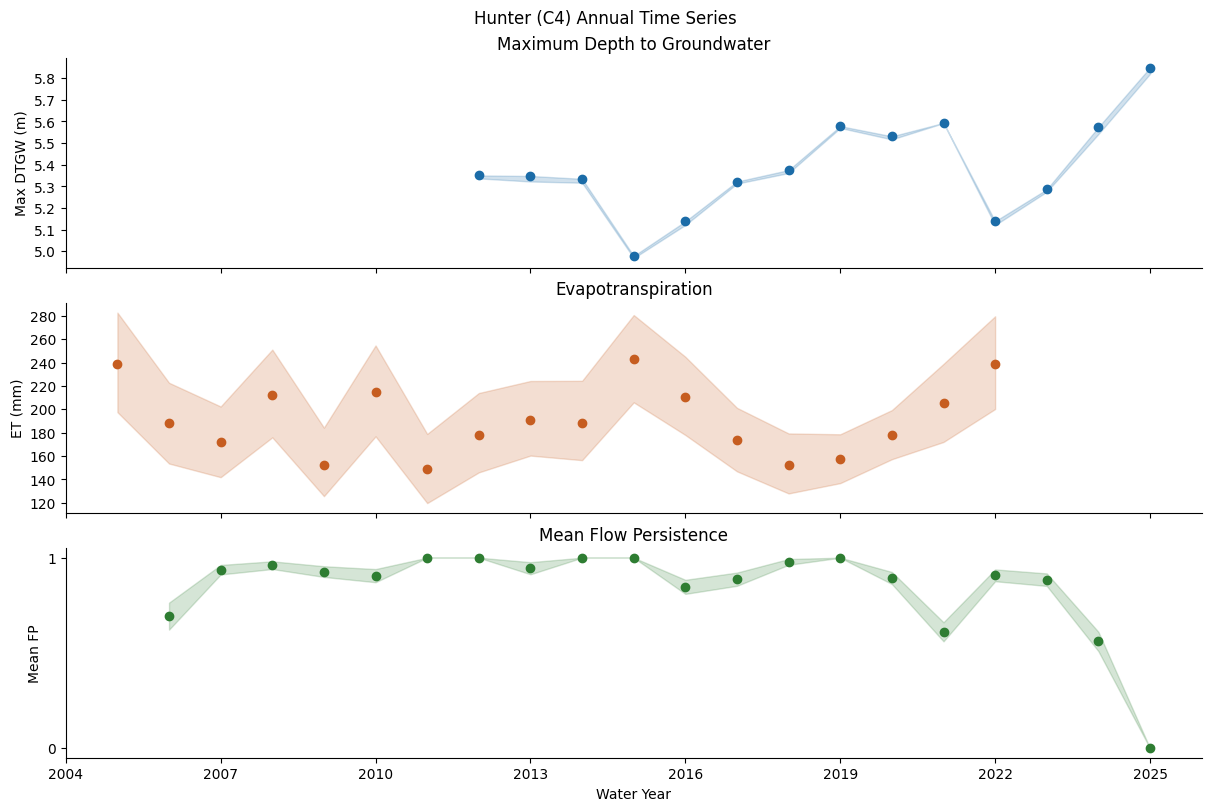

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, layout="constrained")
fig.suptitle("Hunter (C4) Annual Time Series")

axes[0].fill_between(
    annual_groundwater["Water_Year"],
    annual_groundwater["lo"],
    annual_groundwater["hi"],
    color="#1B6CA8",
    alpha=0.2,
)
axes[0].scatter(
    annual_groundwater["Water_Year"],
    annual_groundwater["dtgw"],
    color="#1B6CA8",
    zorder=2,
)
axes[0].set_title("Maximum Depth to Groundwater")
axes[0].set_ylabel("Max DTGW (m)")
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))

axes[1].fill_between(
    annual_et["Water_Year"],
    annual_et["lo"],
    annual_et["hi"],
    color="#C65D20",
    alpha=0.2,
)
axes[1].scatter(
    annual_et["Water_Year"],
    annual_et["ET"],
    color="#C65D20",
    zorder=2,
)
axes[1].set_title("Evapotranspiration")
axes[1].set_ylabel("ET (mm)")
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))

axes[2].fill_between(
    annual_flow_persistence["Water_Year"],
    annual_flow_persistence["lo"],
    annual_flow_persistence["hi"],
    color="#2E7D32",
    alpha=0.2,
)
axes[2].scatter(
    annual_flow_persistence["Water_Year"],
    annual_flow_persistence["mean"],
    color="#2E7D32",
    zorder=2,
)
axes[2].set_title("Mean Flow Persistence")
axes[2].set_ylabel("Mean FP")
axes[2].set_yticks([0, 1], ["0", "1"])
axes[2].set_ylim(-0.05, 1.05)
axes[2].set_xlabel("Water Year")

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
    axis.xaxis.set_major_locator(MaxNLocator(integer=True))

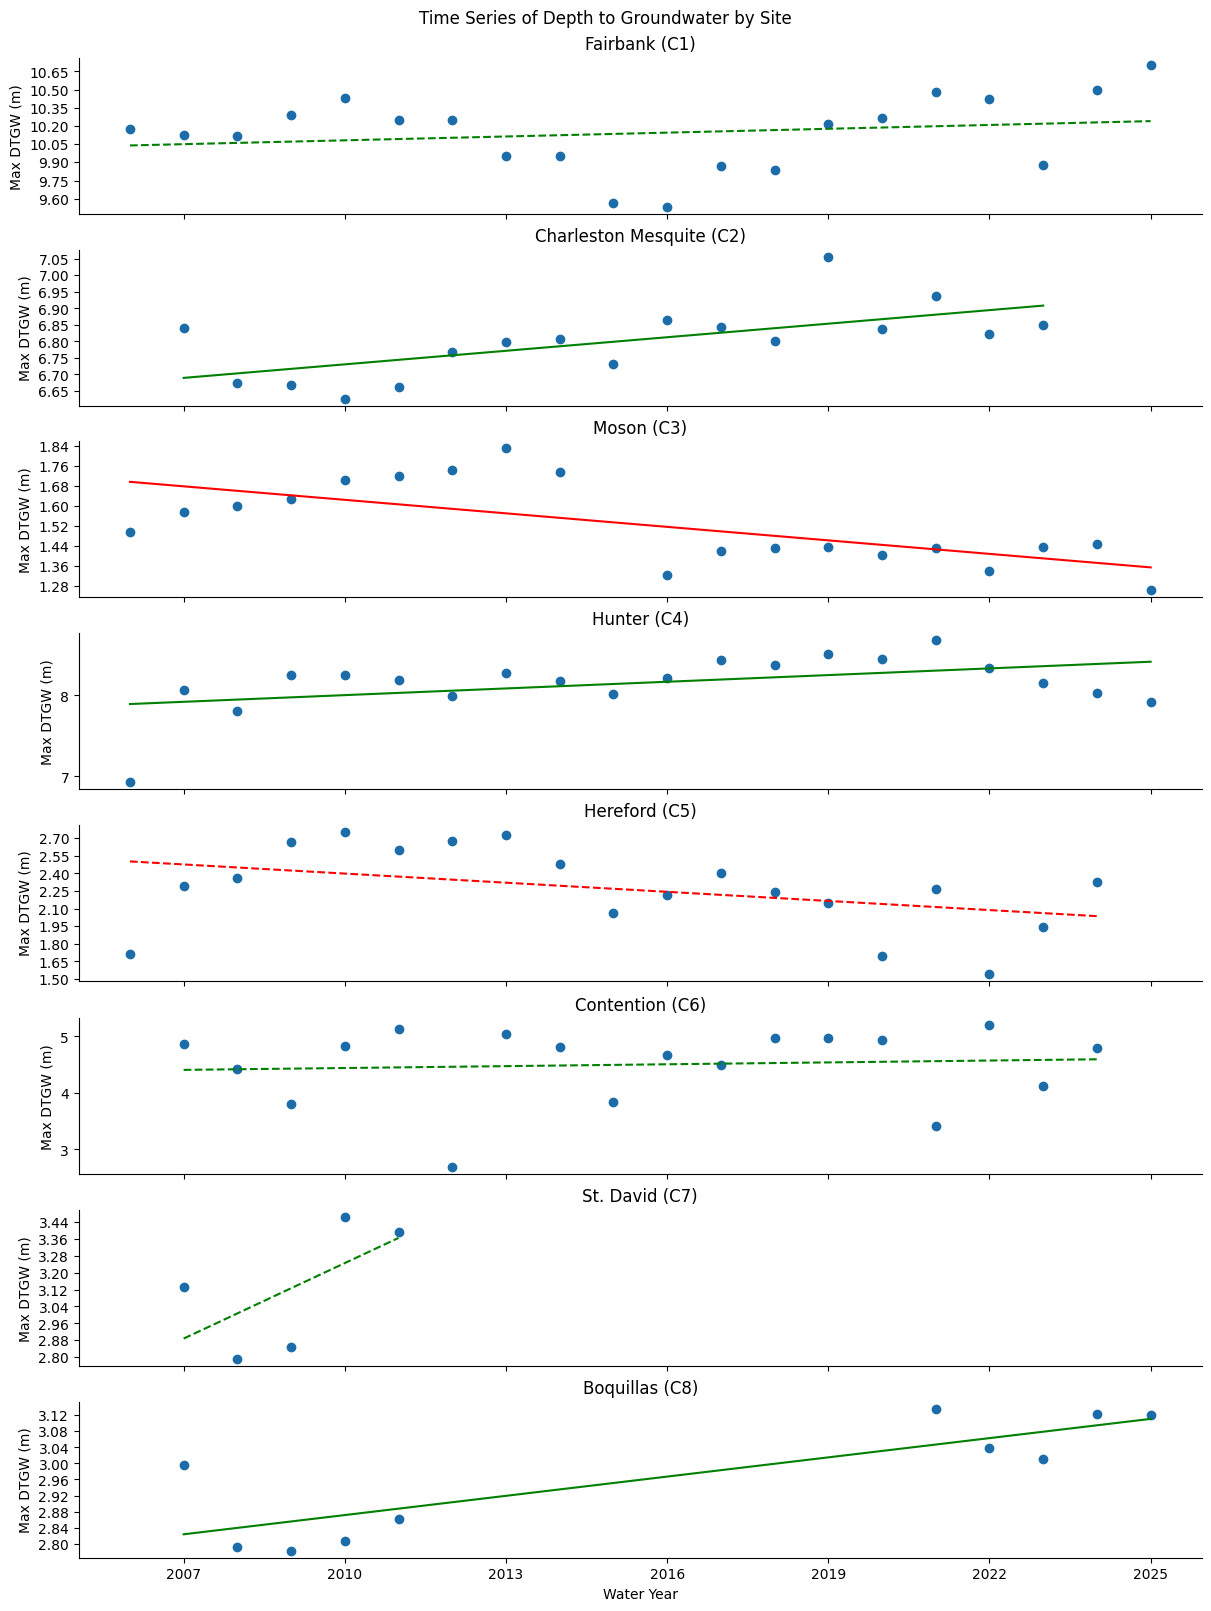

In [4]:
camera_best_well = {
    1: "D-20-21 10AAC2 [FBK-UP]",
    2: "D-20-21 15DDB [BOQ-UP]",
    3: "D-21-21 13BAB1 [MOSLNS]",
    4: "D-22-22 33BBC [HUN-UP]",
    5: "D-23-22 04DCD4 [HERUED]",
    6: "D-19-21 28ACD [TOM-LI]",
    7: "D-19-21 05AAA1 [STD-LI]",
    8: "D-20-21 15DBD1 [BOQ-LI]",
}
shallow_gw = (
    pd.read_csv(DATA / "GW" / "ShallowGW2006_2025.csv")
    .query("site_tp_cd == 'GW' and parameter_cd == 72019")
    .assign(lev_timestamp=lambda data: pd.to_datetime(data["lev_timestamp"]))
    .sort_values("lev_timestamp")
)
shallow_gw["dtgw"] = shallow_gw["lev_va"] * 0.3048

fig, axes = plt.subplots(
    len(camera_best_well), 1, figsize=(12, 16), sharex=True, layout="constrained"
)
fig.suptitle("Time Series of Depth to Groundwater by Site")

for axis, camera in zip(axes, sorted(camera_best_well)):
    site = re.sub(r"(?<!^)(?=[A-Z])", " ", cameras.loc[cameras["Camera"] == camera, "Site"].iloc[0])
    well = camera_best_well[camera]
    series = (
        shallow_gw.loc[shallow_gw["station_nm"] == well, ["lev_timestamp", "dtgw"]]
        .rename(columns={"lev_timestamp": "date"})
    )
    annual = annual_metric_with_ci(series, "dtgw", np.max)
    regression = stats.linregress(annual["Water_Year"], annual["dtgw"])
    line_color = "green" if regression.slope > 0 else "red"
    line_style = "-" if regression.pvalue < 0.05 else "--"
    axis.scatter(annual["Water_Year"], annual["dtgw"], color="#1B6CA8", zorder=2)
    axis.plot(
        annual["Water_Year"],
        regression.slope * annual["Water_Year"] + regression.intercept,
        color=line_color,
        linestyle=line_style,
    )
    axis.set_title(f"{site} (C{camera})")
    axis.set_ylabel("Max DTGW (m)")
    axis.yaxis.set_major_locator(MaxNLocator(integer=True))
    axis.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Water Year")
axes[-1].xaxis.set_major_locator(MaxNLocator(integer=True))

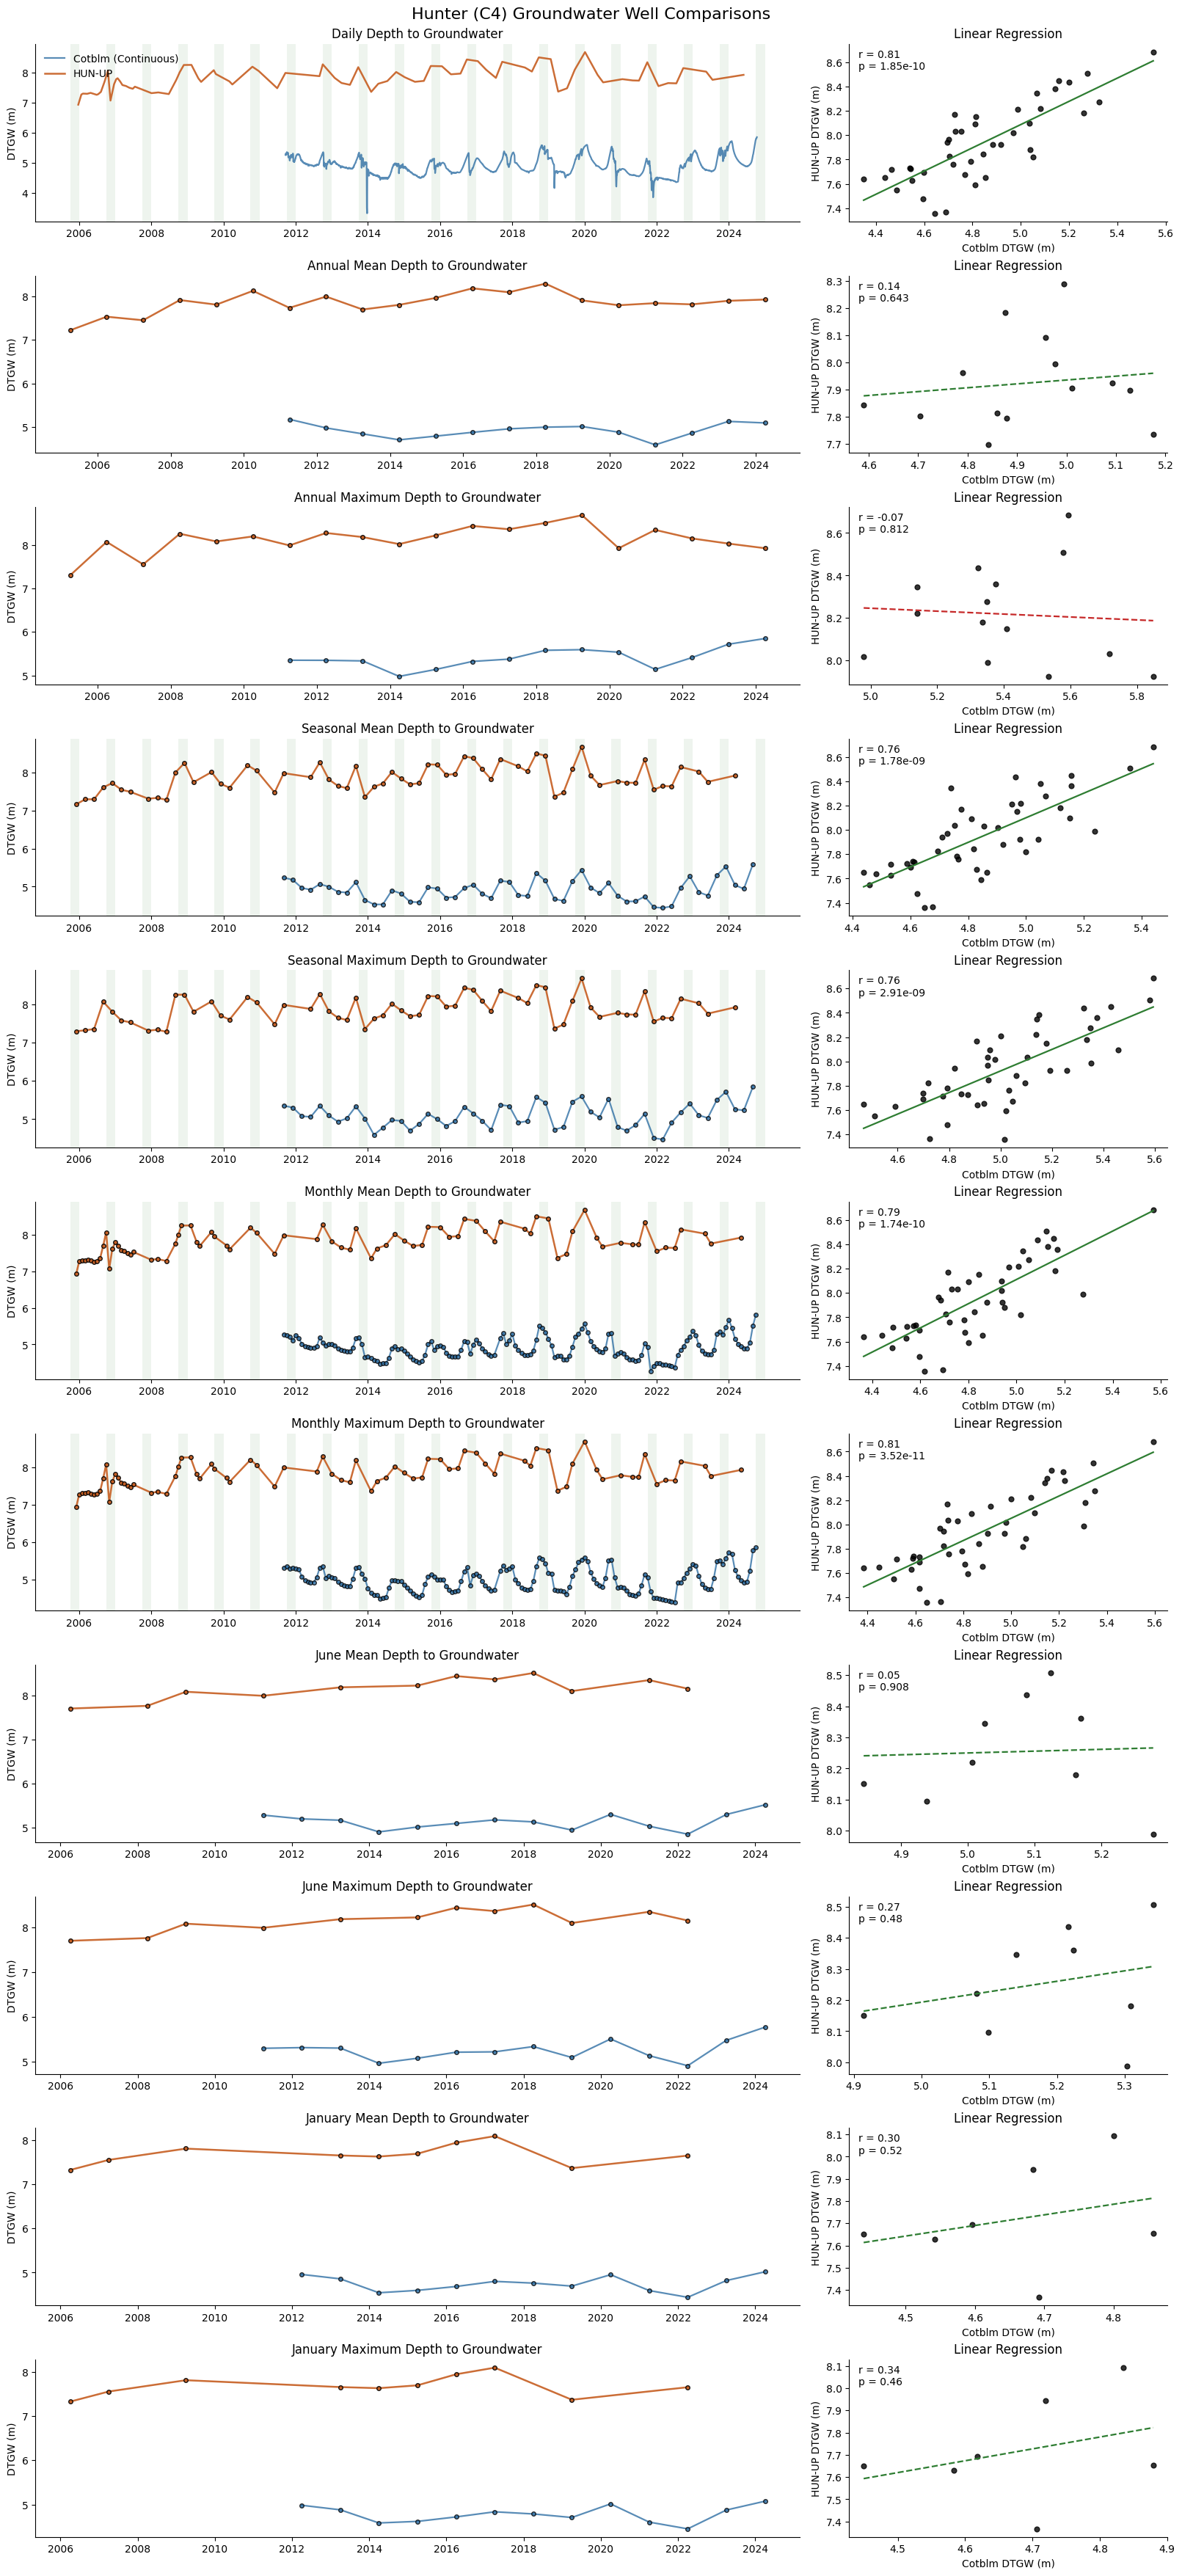

In [5]:
hunter_well = "D-22-22 33BBC [HUN-UP]"

shallow_hunter = (
    pd.read_csv(DATA / "GW" / "ShallowGW2006_2025.csv")
    .query("site_tp_cd == 'GW' and parameter_cd == 72019 and station_nm == @hunter_well")
    .assign(
        date=lambda data: pd.to_datetime(data["lev_timestamp"]),
        dtgw=lambda data: data["lev_va"] * 0.3048,
    )
    [["date", "dtgw"]]
    .sort_values("date")
)

c4_continuous = (
    pd.read_csv(DATA / "GW" / "C4GW.csv", parse_dates=["date"])
    .query("camera == 4")
    [["date", "dtgw"]]
    .assign(dtgw=lambda data: data["dtgw"] * 0.3048)
    .sort_values("date")
)

NWIS = "#2F6FA4"
WHIP = "#C65D20"

def summarize_dtgw(data, frequency, statistic, month=None):
    """Return one DTGW value per requested calendar interval."""
    grouped = data.copy()
    if month is not None:
        grouped = grouped.loc[grouped["date"].dt.month.eq(month)].copy()

    if frequency == "annual":
        grouped["period"] = grouped["date"].dt.to_period("Y")
    elif frequency == "seasonal":
        grouped["period"] = grouped["date"].dt.to_period("Q-NOV")
    elif frequency == "monthly":
        grouped["period"] = grouped["date"].dt.to_period("M")

    return (
        grouped.groupby("period", as_index=False)["dtgw"]
        .agg(statistic)
        .assign(date=lambda data: data["period"].dt.to_timestamp(how="start"))
        [["period", "date", "dtgw"]]
    )

def plot_comparison(series_axis, regression_axis, continuous, shallow, title, raw=False, monsoon=False):
    """Plot matched source series and their linear association."""
    marker_style = {} if raw else {"marker": "o", "markersize": 4, "markeredgecolor": "black"}
    series_axis.plot(
        continuous["date"], continuous["dtgw"], color=NWIS,
        alpha=0.8, linewidth=1.6, label="Cotblm (Continuous)", **marker_style,
    )
    series_axis.plot(
        shallow["date"], shallow["dtgw"], color=WHIP,
        alpha=0.9, linewidth=1.8, label="HUN-UP", **marker_style,
    )

    if raw or monsoon:
        start_year = min(continuous["date"].dt.year.min(), shallow["date"].dt.year.min())
        end_year = max(continuous["date"].dt.year.max(), shallow["date"].dt.year.max())
        for year in range(start_year, end_year + 1):
            series_axis.axvspan(
                pd.Timestamp(year=year, month=7, day=1),
                pd.Timestamp(year=year, month=10, day=1),
                color="#2E7D32", alpha=0.08, linewidth=0, zorder=0,
            )
    if raw:
        series_axis.legend(frameon=False, loc="upper left")

    series_axis.set_title(title)
    series_axis.set_ylabel("DTGW (m)")
    series_axis.yaxis.set_major_locator(MaxNLocator(integer=True))
    series_axis.xaxis.set_major_locator(mdates.YearLocator(base=2, month=10, day=1))
    series_axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    series_axis.spines[["top", "right"]].set_visible(False)

    matched = continuous.merge(shallow, on="period", suffixes=("_continuous", "_shallow")).dropna()
    regression_axis.scatter(
        matched["dtgw_continuous"], matched["dtgw_shallow"],
        color="black", alpha=0.8, s=24,
    )
    if len(matched) >= 3:
        regression = stats.linregress(matched["dtgw_continuous"], matched["dtgw_shallow"])
        x_values = np.array([matched["dtgw_continuous"].min(), matched["dtgw_continuous"].max()])
        line_color = "#2E7D32" if regression.slope >= 0 else "#C62828"
        line_style = "-" if regression.pvalue < 0.05 else "--"
        regression_axis.plot(
            x_values, regression.slope * x_values + regression.intercept,
            color=line_color, linestyle=line_style, linewidth=1.6,
        )
        annotation = f"r = {regression.rvalue:.2f}\np = {regression.pvalue:.3g}"
    else:
        annotation = "Insufficient matched periods"

    regression_axis.set_title("Linear Regression")
    regression_axis.set_xlabel("Cotblm DTGW (m)")
    regression_axis.set_ylabel("HUN-UP DTGW (m)")
    regression_axis.text(
        0.03, 0.97, annotation, transform=regression_axis.transAxes,
        ha="left", va="top",
    )
    regression_axis.spines[["top", "right"]].set_visible(False)

comparison_specs = [
    ("Daily Depth to Groundwater", c4_continuous.assign(period=c4_continuous["date"]), shallow_hunter.assign(period=shallow_hunter["date"]), True, False),
    ("Annual Mean Depth to Groundwater", summarize_dtgw(c4_continuous, "annual", "mean"), summarize_dtgw(shallow_hunter, "annual", "mean"), False, False),
    ("Annual Maximum Depth to Groundwater", summarize_dtgw(c4_continuous, "annual", "max"), summarize_dtgw(shallow_hunter, "annual", "max"), False, False),
    ("Seasonal Mean Depth to Groundwater", summarize_dtgw(c4_continuous, "seasonal", "mean"), summarize_dtgw(shallow_hunter, "seasonal", "mean"), False, True),
    ("Seasonal Maximum Depth to Groundwater", summarize_dtgw(c4_continuous, "seasonal", "max"), summarize_dtgw(shallow_hunter, "seasonal", "max"), False, True),
    ("Monthly Mean Depth to Groundwater", summarize_dtgw(c4_continuous, "monthly", "mean"), summarize_dtgw(shallow_hunter, "monthly", "mean"), False, True),
    ("Monthly Maximum Depth to Groundwater", summarize_dtgw(c4_continuous, "monthly", "max"), summarize_dtgw(shallow_hunter, "monthly", "max"), False, True),
    ("June Mean Depth to Groundwater", summarize_dtgw(c4_continuous, "annual", "mean", month=6), summarize_dtgw(shallow_hunter, "annual", "mean", month=6), False, False),
    ("June Maximum Depth to Groundwater", summarize_dtgw(c4_continuous, "annual", "max", month=6), summarize_dtgw(shallow_hunter, "annual", "max", month=6), False, False),
    ("January Mean Depth to Groundwater", summarize_dtgw(c4_continuous, "annual", "mean", month=1), summarize_dtgw(shallow_hunter, "annual", "mean", month=1), False, False),
    ("January Maximum Depth to Groundwater", summarize_dtgw(c4_continuous, "annual", "max", month=1), summarize_dtgw(shallow_hunter, "annual", "max", month=1), False, False),
]

fig, axes = plt.subplots(
    len(comparison_specs), 2, figsize=(16, 35),
    gridspec_kw={"width_ratios": [2.4, 1]}, layout="constrained",
)
fig.suptitle("Hunter (C4) Groundwater Well Comparisons", fontsize=16)

for (title, continuous, shallow, raw, monsoon), (series_axis, regression_axis) in zip(comparison_specs, axes):
    plot_comparison(
        series_axis, regression_axis, continuous, shallow, title,
        raw=raw, monsoon=monsoon,
    )

In [6]:
def season(dates):
    month = dates.dt.month
    return np.select(
        [month.isin([12, 1, 2, 3]), month.isin([4, 5, 6]), month.isin([7, 8, 9]), month.isin([10, 11])],
        ["CSR", "PMD", "MON", "PMR"],
        default="",
    )

ANALYSIS_CAMERAS = [1, 2, 6, 7]

gw_delta = (
    pd.read_csv(DATA / "GW" / "CamSPRNCA_GW.csv", parse_dates=["datetime"])
    .rename(columns={"datetime": "date", "dtgw_m": "dtgw", "camera": "Camera"})
    [["date", "Camera", "dtgw"]]
    .assign(dtgw=lambda d: d["dtgw"] * 1000)
    .sort_values(["Camera", "date"])
)
gw_delta["Water_Year"] = water_year(gw_delta["date"])
gw_delta["Season"] = season(gw_delta["date"])
gw_delta = gw_delta[gw_delta["Camera"].isin(ANALYSIS_CAMERAS)]

et_all = (
    pd.concat(
        [
            pd.read_csv(DATA / "Jawad_ET" / f"J{index}.csv").assign(Site=site)
            for index, site in enumerate(points["Site"], start=1)
        ],
        ignore_index=True,
    )
    .assign(date=lambda d: pd.to_datetime(d["date"]), ET=lambda d: d["LE_model"] * 0.0353)
    .merge(cameras, on="Site", validate="many_to_one")
)
et_all["Water_Year"] = water_year(et_all["date"])
et_all["Season"] = season(et_all["date"])

flow_all = flow.merge(cameras, on="Site", validate="many_to_one").dropna(subset=["fp"])
flow_all["Water_Year"] = water_year(flow_all["date"])
flow_all["Season"] = season(flow_all["date"])
flow_all = flow_all[flow_all["Camera"].isin(ANALYSIS_CAMERAS)].sort_values(["Camera", "date"])

et_pmd_daily = et_all[et_all["Season"] == "PMD"].sort_values(["Camera", "Water_Year", "date"]).copy()
et_pmd_daily["cum_ET"] = et_pmd_daily.groupby(["Camera", "Water_Year"])["ET"].cumsum()

mon_gw = gw_delta.query("Season == 'MON'")
gw_mon_min = (
    mon_gw.loc[mon_gw.groupby(["Camera", "Water_Year"])["dtgw"].idxmin()]
    [["Camera", "Water_Year", "dtgw", "date"]]
    .rename(columns={"dtgw": "gw_mon_min", "date": "gw_mon_min_date"})
)

gw_points = (
    gw_delta.query("Season == 'PMD'")[["Camera", "Water_Year", "date", "dtgw"]]
    .merge(et_pmd_daily[["Camera", "Water_Year", "date", "cum_ET"]], on=["Camera", "Water_Year", "date"])
    .merge(gw_mon_min, on=["Camera", "Water_Year"])
)
gw_points["delta"] = gw_points["dtgw"] - gw_points["gw_mon_min"]
gw_points["days_to_min"] = (gw_points["gw_mon_min_date"] - gw_points["date"]).dt.days
gw_points["delta_a"] = gw_points["delta"] - gw_points.groupby("Camera")["delta"].transform("mean")
gw_points["cum_ET_a"] = gw_points["cum_ET"] - gw_points.groupby("Camera")["cum_ET"].transform("mean")

et_seasonal = et_all.groupby(["Camera", "Water_Year", "Season"], as_index=False)["ET"].sum()
fp_seasonal = flow_all.groupby(["Camera", "Water_Year", "Season"], as_index=False)["fp"].mean()

et_pmd_total = et_seasonal.query("Season == 'PMD'")[["Camera", "Water_Year", "ET"]].rename(columns={"ET": "et_pmd"})
et_mon_total = et_seasonal.query("Season == 'MON'")[["Camera", "Water_Year", "ET"]].rename(columns={"ET": "et_mon"})
fp_mon_total = fp_seasonal.query("Season == 'MON'")[["Camera", "Water_Year", "fp"]].rename(columns={"fp": "fp_mon"})

fp_story = (
    et_pmd_total.merge(et_mon_total, on=["Camera", "Water_Year"])
    .merge(fp_mon_total, on=["Camera", "Water_Year"])
)
fp_story = fp_story[fp_story["Camera"].isin(ANALYSIS_CAMERAS)]
for column in ["et_pmd", "et_mon", "fp_mon"]:
    fp_story[f"{column}_a"] = fp_story[column] - fp_story.groupby("Camera")[column].transform("mean")

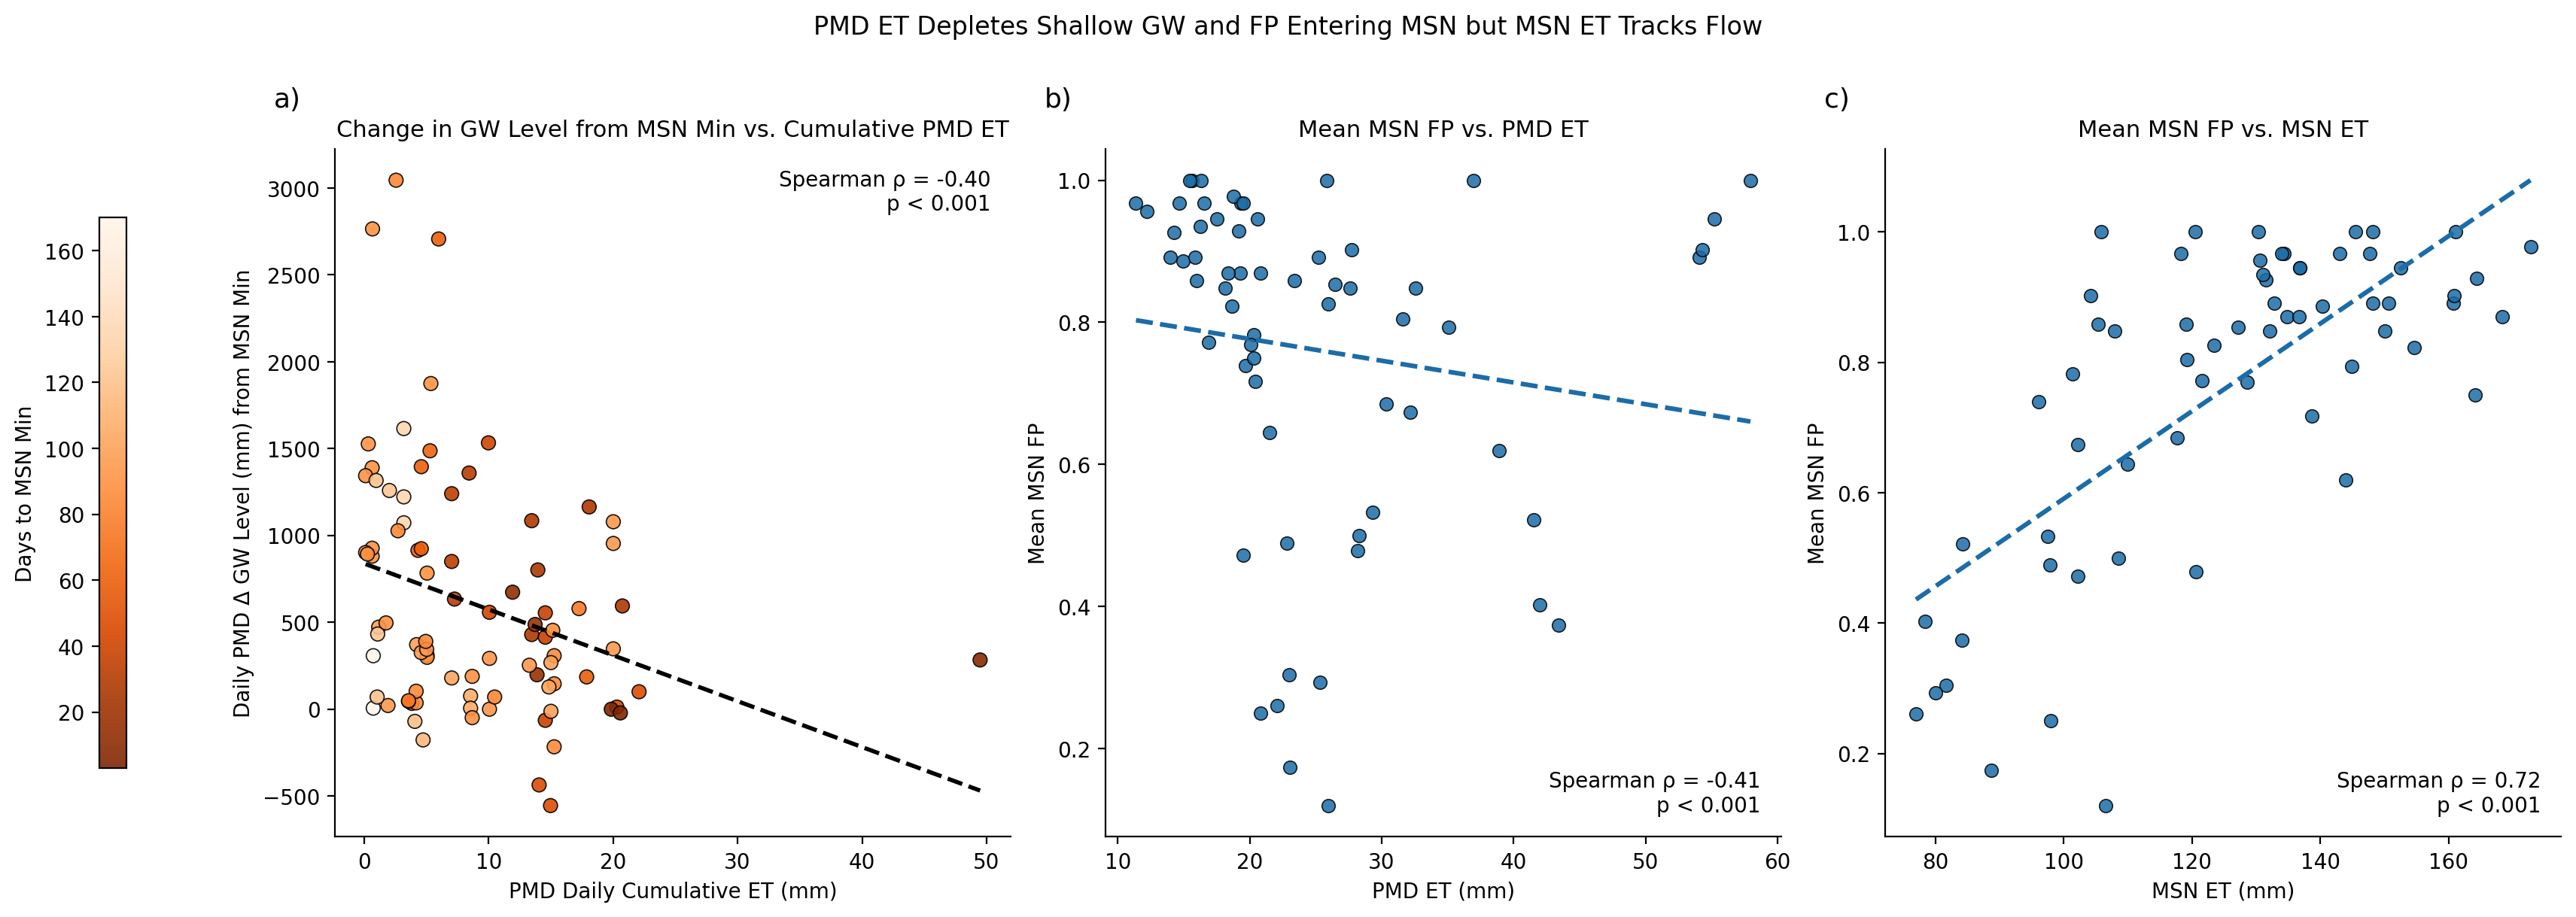

In [7]:
PMD_COLOR = "#1B6CA8"
MON_COLOR = "#1B6CA8"

def p_label(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3g}"

def panel_label(axis, label):
    axis.text(
        -0.09, 1.09, label, transform=axis.transAxes, ha="left", va="top",
        fontsize=13, clip_on=False,
    )

def cumulative_panel(axis, data, x_col, y_col, color_col, xlabel, ylabel, title, label):
    spearman_rho, spearman_p = stats.spearmanr(data[f"{x_col}_a"], data[f"{y_col}_a"])
    fit = stats.linregress(data[x_col], data[y_col])
    x_values = np.array([data[x_col].min(), data[x_col].max()])
    axis.plot(x_values, fit.intercept + fit.slope * x_values, color="black", linestyle="--", linewidth=2, zorder=3)
    scatter = axis.scatter(
        data[x_col], data[y_col], c=data[color_col], cmap="Oranges_r",
        edgecolor="black", linewidth=0.6, alpha=0.9, s=45, zorder=2,
    )
    axis.text(
        0.97, 0.97,
        f"Spearman ρ = {spearman_rho:.2f}\n{p_label(spearman_p)}",
        transform=axis.transAxes, ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2), fontsize=10,
    )
    panel_label(axis, label)
    axis.set_title(title, fontsize=11)
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    axis.spines[["top", "right"]].set_visible(False)
    return scatter

def seasonal_panel(axis, data, x_col, y_col, color, xlabel, ylabel, title, label):
    spearman_rho, spearman_p = stats.spearmanr(data[f"{x_col}_a"], data[f"{y_col}_a"])
    fit = stats.linregress(data[x_col], data[y_col])
    x_values = np.array([data[x_col].min(), data[x_col].max()])
    axis.plot(x_values, fit.intercept + fit.slope * x_values, color=color, linestyle="--", linewidth=2.2, zorder=3)
    axis.scatter(data[x_col], data[y_col], color=color, edgecolor="black", linewidth=0.6, alpha=0.85, s=40, zorder=2)
    axis.text(
        0.97, 0.03,
        f"Spearman ρ = {spearman_rho:.2f}\n{p_label(spearman_p)}",
        transform=axis.transAxes, ha="right", va="bottom",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2), fontsize=10,
    )
    panel_label(axis, label)
    axis.set_title(title, fontsize=11)
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    axis.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), layout="constrained")
fig.suptitle("PMD ET Depletes Shallow GW and FP Entering MSN but MSN ET Tracks Flow", y=1.08)

scatter = cumulative_panel(
    axes[0], gw_points, "cum_ET", "delta", "days_to_min",
    "PMD Daily Cumulative ET (mm)", "Daily PMD Δ GW Level (mm) from MSN Min",
    "Change in GW Level from MSN Min vs. Cumulative PMD ET", "a)",
)
fig.colorbar(scatter, ax=axes[0], label="Days to MSN Min", shrink=0.8, location="left", pad=0.15)

seasonal_panel(
    axes[1], fp_story, "et_pmd", "fp_mon", PMD_COLOR,
    "PMD ET (mm)", "Mean MSN FP",
    "Mean MSN FP vs. PMD ET", "b)",
)
seasonal_panel(
    axes[2], fp_story, "et_mon", "fp_mon", MON_COLOR,
    "MSN ET (mm)", "Mean MSN FP",
    "Mean MSN FP vs. MSN ET", "c)",
)

%config InlineBackend.figure_format = "retina"

# plt.savefig("../Figures/cumulative_et_gw.png", format = "png", dpi = 300, bbox_inches = "tight")

In [8]:
c4_calendar = (
    et_all.query("Camera == 4")[["date", "ET", "Precip"]]
    .dropna(subset=["ET"])
    .assign(doy=lambda d: d["date"].dt.dayofyear)
    .query("doy <= 365")
    .groupby("doy")[["ET", "Precip"]]
    .mean()
    .reset_index()
    .assign(
        cum_ET=lambda d: d["ET"].cumsum(),
        cum_Precip=lambda d: d["Precip"].cumsum(),
        calendar_date=lambda d: pd.Timestamp("2001-01-01") + pd.to_timedelta(d["doy"] - 1, unit="D"),
    )
)

c4_gw_calendar = (
    c4_continuous
    .assign(height_above_lowest=lambda d: (d["dtgw"].max() - d["dtgw"]) * 1000)
    .assign(doy=lambda d: d["date"].dt.dayofyear)
    .query("doy <= 365")
    .groupby("doy")["height_above_lowest"]
    .mean()
    .reset_index()
    .assign(calendar_date=lambda d: pd.Timestamp("2001-01-01") + pd.to_timedelta(d["doy"] - 1, unit="D"))
)

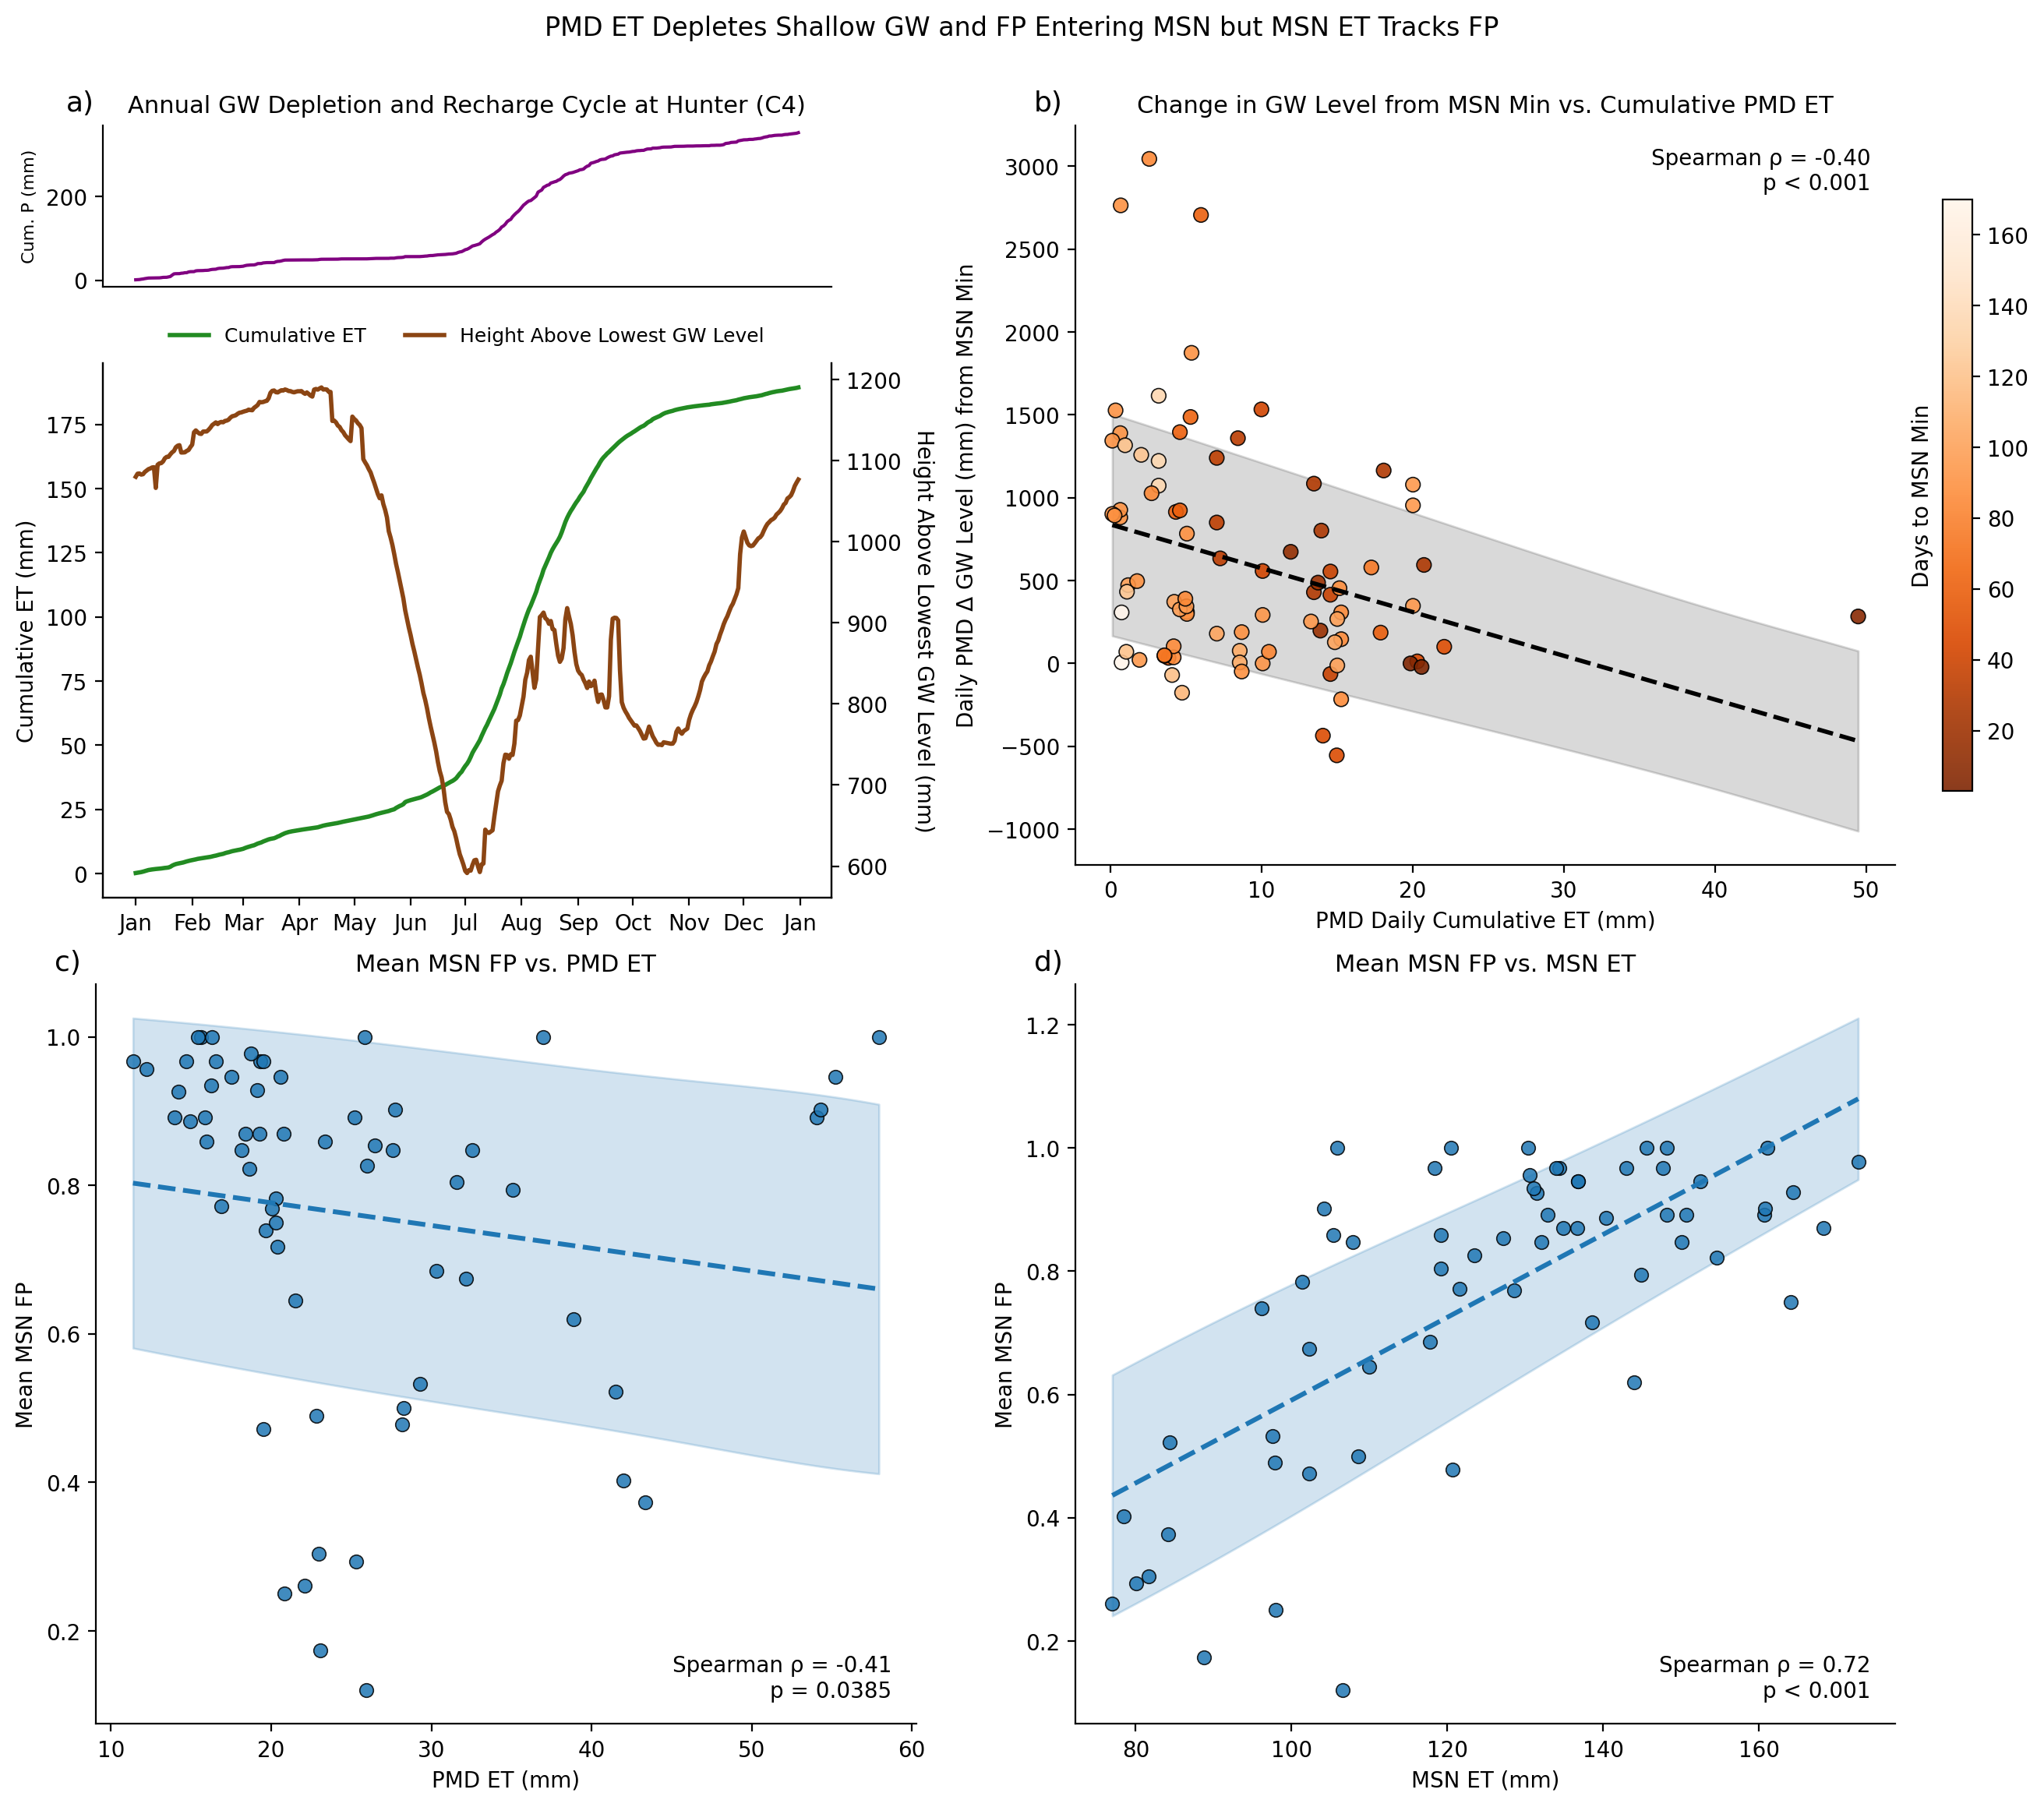

In [ ]:
PMD_COLOR = "tab:blue"
MON_COLOR = "tab:blue"
ET_COLOR = "forestgreen"
GW_COLOR = "saddlebrown"
PRECIP_COLOR = "purple"

def p_label(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3g}"

def panel_label(axis, label, offset_points=4):
    transform = mtransforms.offset_copy(axis.transAxes, fig=fig, x=0, y=offset_points, units="points")
    axis.text(
        -0.05, 1.0, label, transform=transform, ha="left", va="bottom",
        fontsize=13, clip_on=False,
    )

def regression_band(x, y, n_points=200, bandwidth_frac=0.3):
    """Linear trendline with a locally-varying data standard-deviation band."""
    x = x.to_numpy()
    y = y.to_numpy()
    fit = stats.linregress(x, y)
    residuals = y - (fit.intercept + fit.slope * x)
    x_grid = np.linspace(x.min(), x.max(), n_points)
    y_grid = fit.intercept + fit.slope * x_grid
    bandwidth = bandwidth_frac * (x.max() - x.min())
    local_std = np.empty(n_points)
    for i, x0 in enumerate(x_grid):
        weights = np.exp(-0.5 * ((x - x0) / bandwidth) ** 2)
        weighted_mean_resid = np.sum(weights * residuals) / weights.sum()
        variance = np.sum(weights * (residuals - weighted_mean_resid) ** 2) / weights.sum()
        local_std[i] = np.sqrt(variance)
    return x_grid, y_grid, local_std

def cluster_bootstrap_spearman(data, x_col, y_col, cluster_cols, n_boot=2000):
    """Two-sided bootstrap p-value for Spearman rho, resampling whole clusters to respect non-independence."""
    groups = [(group[x_col].to_numpy(), group[y_col].to_numpy()) for _, group in data.groupby(cluster_cols)]
    observed_rho, _ = stats.spearmanr(data[x_col], data[y_col])
    boot_rhos = np.empty(n_boot)
    for i in range(n_boot):
        sampled = rng.integers(0, len(groups), size=len(groups))
        x_boot = np.concatenate([groups[j][0] for j in sampled])
        y_boot = np.concatenate([groups[j][1] for j in sampled])
        boot_rhos[i] = stats.spearmanr(x_boot, y_boot)[0]
    p_value = (np.sum(np.abs(boot_rhos - observed_rho) >= np.abs(observed_rho)) + 1) / (n_boot + 1)
    return observed_rho, p_value

def cumulative_panel(axis, data, x_col, y_col, color_col, cluster_cols, xlabel, ylabel, title, label):
    spearman_rho, spearman_p = cluster_bootstrap_spearman(data, f"{x_col}_a", f"{y_col}_a", cluster_cols)
    x_fit, y_fit, local_std = regression_band(data[x_col], data[y_col])
    axis.fill_between(x_fit, y_fit - local_std, y_fit + local_std, color="black", alpha=0.15, zorder=1)
    axis.plot(x_fit, y_fit, color="black", linestyle="--", linewidth=2, zorder=3)
    scatter = axis.scatter(
        data[x_col], data[y_col], c=data[color_col], cmap="Oranges_r",
        edgecolor="black", linewidth=0.6, alpha=0.9, s=45, zorder=2,
    )
    axis.text(
        0.97, 0.97,
        f"Spearman ρ = {spearman_rho:.2f}\n{p_label(spearman_p)}",
        transform=axis.transAxes, ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2), fontsize=10,
    )
    panel_label(axis, label)
    axis.set_title(title, fontsize=11)
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    axis.spines[["top", "right"]].set_visible(False)
    return scatter

def seasonal_panel(axis, data, x_col, y_col, color, cluster_cols, xlabel, ylabel, title, label):
    spearman_rho, spearman_p = cluster_bootstrap_spearman(data, f"{x_col}_a", f"{y_col}_a", cluster_cols)
    x_fit, y_fit, local_std = regression_band(data[x_col], data[y_col])
    axis.fill_between(x_fit, y_fit - local_std, y_fit + local_std, color=color, alpha=0.2, zorder=1)
    axis.plot(x_fit, y_fit, color=color, linestyle="--", linewidth=2.2, zorder=3)
    axis.scatter(data[x_col], data[y_col], color=color, edgecolor="black", linewidth=0.6, alpha=0.85, s=40, zorder=2)
    axis.text(
        0.97, 0.03,
        f"Spearman ρ = {spearman_rho:.2f}\n{p_label(spearman_p)}",
        transform=axis.transAxes, ha="right", va="bottom",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2), fontsize=10,
    )
    panel_label(axis, label)
    axis.set_title(title, fontsize=11)
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    axis.spines[["top", "right"]].set_visible(False)

fig = plt.figure(figsize=(13, 11), layout="constrained")
fig.suptitle("PMD ET Depletes Shallow GW and FP Entering MSN but MSN ET Tracks FP", y=1.04)

grid = fig.add_gridspec(2, 2, wspace=0.03)
grid_a = grid[0, 0].subgridspec(2, 1, height_ratios=[1, 3.3], hspace=0.03)
precip_axis = fig.add_subplot(grid_a[0])
calendar_axis = fig.add_subplot(grid_a[1], sharex=precip_axis)
axis_b = fig.add_subplot(grid[0, 1])
axis_c = fig.add_subplot(grid[1, 0])
axis_d = fig.add_subplot(grid[1, 1])

precip_axis.plot(
    c4_calendar["calendar_date"], c4_calendar["cum_Precip"],
    color=PRECIP_COLOR, linewidth=1.5,
)
precip_axis.set_ylabel("Cum. P (mm)", fontsize=8)
precip_axis.spines[["top", "right"]].set_visible(False)
precip_axis.tick_params(axis="x", labelbottom=False, bottom=False)
panel_label(precip_axis, "a)")
precip_axis.set_title("Annual GW Depletion and Recharge Cycle at Hunter (C4)", fontsize=11)

et_line, = calendar_axis.plot(
    c4_calendar["calendar_date"], c4_calendar["cum_ET"],
    color=ET_COLOR, linewidth=2, label="Cumulative ET",
)
calendar_axis.set_ylabel("Cumulative ET (mm)", color="black")
calendar_axis.tick_params(axis="y", labelcolor="black")
calendar_axis.xaxis.set_major_locator(mdates.MonthLocator())
calendar_axis.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
calendar_axis.spines["top"].set_visible(False)

gw_axis = calendar_axis.twinx()
gw_line, = gw_axis.plot(
    c4_gw_calendar["calendar_date"], c4_gw_calendar["height_above_lowest"],
    color=GW_COLOR, linewidth=2, label="Height Above Lowest GW Level",
)
gw_axis.set_ylabel("Height Above Lowest GW Level (mm)", color="black", rotation=-90, labelpad=15)
gw_axis.tick_params(axis="y", labelcolor="black")
gw_axis.spines["top"].set_visible(False)

calendar_axis.legend(
    handles=[et_line, gw_line], loc="lower center", bbox_to_anchor=(0.5, 1.0),
    ncol=2, frameon=False, fontsize=9,
)

scatter = cumulative_panel(
    axis_b, gw_points, "cum_ET", "delta", "days_to_min", ["Camera", "Water_Year"],
    "PMD Daily Cumulative ET (mm)", "Daily PMD Δ GW Level (mm) from MSN Min",
    "Change in GW Level from MSN Min vs. Cumulative PMD ET", "b)",
)
colorbar = fig.colorbar(scatter, ax=axis_b, shrink=0.8, location="right", pad=0.02)
colorbar.set_label("Days to MSN Min")
colorbar.ax.yaxis.set_label_position("left")

seasonal_panel(
    axis_c, fp_story, "et_pmd", "fp_mon", PMD_COLOR, "Water_Year",
    "PMD ET (mm)", "Mean MSN FP",
    "Mean MSN FP vs. PMD ET", "c)",
)
seasonal_panel(
    axis_d, fp_story, "et_mon", "fp_mon", MON_COLOR, "Water_Year",
    "MSN ET (mm)", "Mean MSN FP",
    "Mean MSN FP vs. MSN ET", "d)",
)

%config InlineBackend.figure_format = "retina"

# plt.savefig("../Figures/cumulative_et_gw_cycle.png", format = "png", dpi = 300, bbox_inches = "tight")